## Ridge and LAsso Regression implementation

In [6]:
from sklearn.datasets import fetch_california_housing


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df=fetch_california_housing()

In [9]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [10]:
dataset = pd.DataFrame(df.data)
print(dataset.head())

        0     1         2         3       4         5      6       7
0  8.3252  41.0  6.984127  1.023810   322.0  2.555556  37.88 -122.23
1  8.3014  21.0  6.238137  0.971880  2401.0  2.109842  37.86 -122.22
2  7.2574  52.0  8.288136  1.073446   496.0  2.802260  37.85 -122.24
3  5.6431  52.0  5.817352  1.073059   558.0  2.547945  37.85 -122.25
4  3.8462  52.0  6.281853  1.081081   565.0  2.181467  37.85 -122.25


In [11]:
dataset.columns=df.feature_names

In [12]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [13]:
df.target.shape

(20640,)

In [14]:
dataset["Price"]=df.target

In [15]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [16]:
X=dataset.iloc[:,:-1] ## independent features
y=dataset.iloc[:,-1] ## dependent features

## Linear Regression


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lin_regressor=LinearRegression()
# negative mean squared error is used because cross_val_score by default tries to maximize the score, and MSE is a loss function that we want to minimize. By negating it, we can use it with cross_val_score to get the correct results.
# The cv=5 argument specifies that we want to use 5-fold cross-validation, which means that the dataset will be split into 5 subsets, and the model will be trained and evaluated 5 times, each time using a different subset as the test set and the remaining subsets as the training set.
mse=cross_val_score(lin_regressor,X,y,scoring='neg_mean_squared_error',cv=5) 
mean_mse=np.mean(mse)
print(mean_mse)

-0.5582901717686536


## Ridge Regression

In [35]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge=Ridge()
# alpha is the regularization strength parameter for Ridge regression. It controls the amount of shrinkage applied to the coefficients. A higher alpha value will result in more shrinkage, which can help prevent overfitting but may also lead to underfitting if set too high. The GridSearchCV will search for the best alpha value from the specified list of values by evaluating the model's performance using cross-validation and selecting the one that minimizes the mean squared error.
# The scoring='neg_mean_squared_error' argument specifies that we want to use the negative mean squared error as the evaluation metric for the GridSearchCV. This is because GridSearchCV tries to maximize the score, and since mean squared error is a loss function that we want to minimize, we negate it to get the correct results.
# alpha value is a hyperparameter that controls the strength of the regularization in Ridge regression. It determines how much the coefficients are shrunk towards zero. A higher alpha value will result in more shrinkage, which can help prevent overfitting but may also lead to underfitting if set too high. The GridSearchCV will search for the best alpha value from the specified list of values by evaluating the model's performance using cross-validation and selecting the one that minimizes the mean squared error.
# [1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100] is a list of alpha values that we want to search through in the GridSearchCV. These values represent different levels of regularization strength, ranging from very small (1e-15) to very large (100). The GridSearchCV will evaluate the model's performance for each of these alpha values and select the one that minimizes the mean squared error.
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
# The verbose=1 argument in GridSearchCV is used to control the verbosity of the output during the fitting process. When set to 1, it will print messages about the progress of the grid search, including which parameter combination is currently being evaluated and the corresponding score. This can be helpful for monitoring the progress of the grid search and understanding how long it might take to complete.
ridge_regressor=GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5 , verbose=1)
ridge_regressor.fit(X,y)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,Ridge()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,55


In [36]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 55}
-0.557944491705302


## Lasso Regression

In [37]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso=Lasso()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5 , verbose=1)

lasso_regressor.fit(X,y)


Fitting 5 folds for each of 16 candidates, totalling 80 fits


c:\Users\nayak\anaconda3\envs\ineuron_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.906e+03, tolerance: 2.228e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\nayak\anaconda3\envs\ineuron_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.113e+02, tolerance: 2.256e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\nayak\anaconda3\envs\ineuron_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

,estimator,Lasso()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.001


In [38]:
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

{'alpha': 0.001}
-0.5582759293868984


In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [40]:
prediction_lasso=lasso_regressor.predict(X_test)
prediction_ridge=ridge_regressor.predict(X_test)

C:\Users\nayak\AppData\Local\Temp\ipykernel_11520\1196053527.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-prediction_lasso)


<Axes: xlabel='Price', ylabel='Density'>

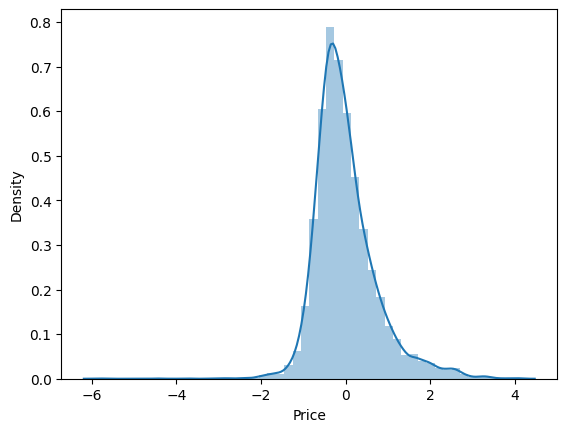

In [ ]:
import seaborn as sns

# plotting the distribution of the residuals (the difference between the actual values and the predicted values) for the Lasso regression model. This can help us understand how well the model is fitting the data and whether there are any patterns in the residuals that might indicate issues with the model.

sns.distplot(y_test-prediction_lasso)

C:\Users\nayak\AppData\Local\Temp\ipykernel_11520\3356612006.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-prediction_ridge)


<Axes: xlabel='Price', ylabel='Density'>

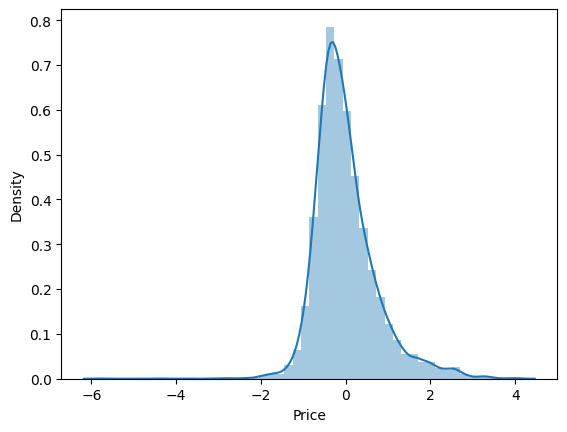

In [42]:
import seaborn as sns

sns.distplot(y_test-prediction_ridge)